In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision.datasets import MNIST
from torchvision import transforms
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import torch
from PIL import Image

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,),(0.3081,))   # these are standard normalization numbers specific for the MNIST dataset
])

gpu_params = {
    "batch_size": 1024,
    "num_workers": 4,
    "pin_memory": True
}

# these values are specifically good for the NVIDIA 4060, may change on other computers

train_dataset = MNIST(root='./data', train=True, download=True, transform=transform)

train_loader = DataLoader(
    train_dataset, 
    batch_size=gpu_params["batch_size"], 
    shuffle=True, num_workers=gpu_params["num_workers"], 
    pin_memory=gpu_params["pin_memory"]
)

test_dataset = MNIST(root='./data', train=False, download=True, transform=transform)
test_loader = DataLoader(
    test_dataset, 
    batch_size=gpu_params["batch_size"], 
    shuffle=False, 
    num_workers=gpu_params["num_workers"], 
    pin_memory=gpu_params["pin_memory"]
)

print(f"We have a Training Set of {len(train_dataset)} images and a Test Set of {test_dataset} images.")

image, label = train_dataset[0]

100%|██████████| 9.91M/9.91M [00:04<00:00, 2.26MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 188kB/s]
100%|██████████| 1.65M/1.65M [00:02<00:00, 645kB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 17.3MB/s]

We have a Training Set of 60000 images and a Test Set of Dataset MNIST
    Number of datapoints: 10000
    Root location: ./data
    Split: Test
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.1307,), std=(0.3081,))
           ) images.


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")   # this changes the device being used for calculations, since i have a nvidia gpu cuda will serve as a service to make use of the gpu
print(f"Device {device}")

Device cuda


In [3]:
class MNISTClassifier(nn.Module):
    def __init__(self, filters=[1,64,128,256], layers=[512,256], image_width=28, output=10, kernel_size=3, padding=1, pooling=2,dropout_rate=0.2):
        super().__init__()
        self.conv1 = nn.Conv2d(
            in_channels=filters[0],         # 1 color channel (black/white)
            out_channels=filters[1],        # 128 patterns (filters)
            kernel_size=kernel_size,        # subimage analyzed
            padding=padding
        )       
        # it analyzes the 28x28 image for 128 patterns, then it center it for a 14x14 subimage
        self.pool1 = nn.MaxPool2d(pooling,pooling)
        image_width //= 2

        self.conv2 = nn.Conv2d(
            in_channels=filters[1],         # 128 input channels 
            out_channels=filters[2],        # 256 filters
            kernel_size=kernel_size, 
            padding=padding
        )       
        # repeat
        self.pool2 = nn.MaxPool2d(pooling,pooling)
        image_width //= 2

        self.conv3 = nn.Conv2d(
            in_channels=filters[2],         # 256 input
            out_channels=filters[3],        # 512 filters
            kernel_size=kernel_size, 
            padding=padding
        )
        # repeat again
        self.pool3 = nn.MaxPool2d(pooling,pooling)
        image_width //= 2

        self.fc1 = nn.Linear(filters[3] * image_width**2, layers[0])    # we compress the result of convolution into 512 neurons
        self.fc2 = nn.Linear(layers[0], layers[1])                      # same old neural network stuff, compress from 512 neurons to 256
        self.fc3 = nn.Linear(layers[1], output)                         # gives out a class out of 10 possible output neurons
        self.dropout = nn.Dropout(dropout_rate)                         # the dropout prevents the overfitting
        self.relu = nn.ReLU()                                           # only positive values

    def forward(self, x):
        x = self.pool1(self.relu(self.conv1(x)))
        x = self.pool2(self.relu(self.conv2(x)))
        x = self.pool3(self.relu(self.conv3(x)))
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        return x

In [4]:
model = MNISTClassifier().to(device)

Epoch 1, Loss 0.5570
Epoch 2, Loss 0.0804
Epoch 3, Loss 0.0515
Epoch 4, Loss 0.0345
Epoch 5, Loss 0.0340
Epoch 6, Loss 0.0245
Epoch 7, Loss 0.0187
Epoch 8, Loss 0.0190
Epoch 9, Loss 0.0146
Epoch 10, Loss 0.0108
Epoch 11, Loss 0.0105
Epoch 12, Loss 0.0093
Epoch 13, Loss 0.0079
Epoch 14, Loss 0.0075
Epoch 15, Loss 0.0091
Epoch 16, Loss 0.0076
Epoch 17, Loss 0.0057
Epoch 18, Loss 0.0050
Epoch 19, Loss 0.0068
Epoch 20, Loss 0.0042
Epoch 21, Loss 0.0039
Epoch 22, Loss 0.0052
Epoch 23, Loss 0.0052
Epoch 24, Loss 0.0057
Epoch 25, Loss 0.0030
Epoch 26, Loss 0.0025
Epoch 27, Loss 0.0032
Epoch 28, Loss 0.0031
Epoch 29, Loss 0.0045
Epoch 30, Loss 0.0025
Epoch 31, Loss 0.0018
Epoch 32, Loss 0.0048
Epoch 33, Loss 0.0036
Epoch 34, Loss 0.0015
Epoch 35, Loss 0.0036
Epoch 36, Loss 0.0040
Epoch 37, Loss 0.0018
Epoch 38, Loss 0.0025
Epoch 39, Loss 0.0043
Epoch 40, Loss 0.0025
Epoch 41, Loss 0.0035
Epoch 42, Loss 0.0047
Epoch 43, Loss 0.0047
Epoch 44, Loss 0.0010
Epoch 45, Loss 0.0016
Epoch 46, Loss 0.00

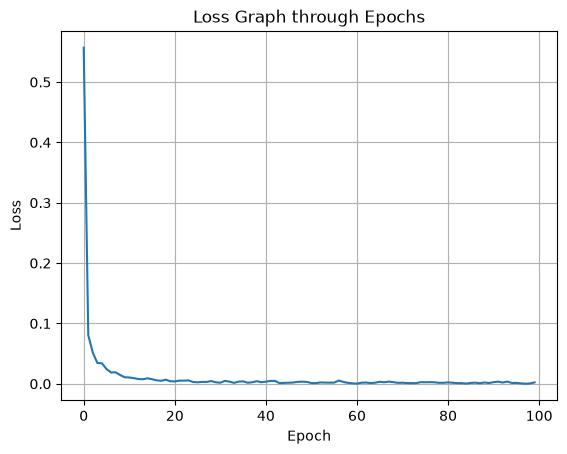

In [5]:
lf = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
epochs = 100

train_losses = []

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)       # transfers the images and labels to the gpu memory so that it can use them for calculations
        outputs = model(images)
        loss = lf(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f"Epoch {epoch + 1}, Loss {avg_loss:.4f}")

plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Graph through Epochs")
plt.grid(True)
plt.show()

In [6]:
def eval(model, data_loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return correct / total

acc = eval(model, test_loader)
print(f"Accuracy {acc*100:.2f}%")

Accuracy 99.20%


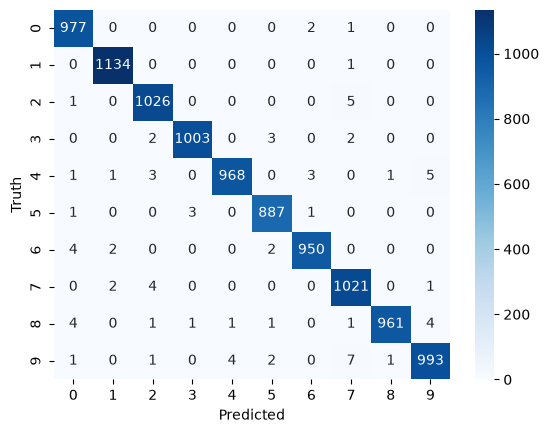

In [7]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Truth")
plt.show()

In [8]:
torch.save(model.state_dict(), 'mnist.pth')

In [ ]:
def predict_my_number(image_path, model, device):
    image = Image.open(image_path).convert('L')  
    
    transform = transforms.Compose([
        transforms.Resize((28, 28)),          
        transforms.ToTensor(),                
        transforms.Normalize((0.1307,), (0.3081,)) 
    ])
    
    image_tensor = transform(image).unsqueeze(0).to(device)  
    
    plt.imshow(image_tensor.squeeze(0).squeeze(0).cpu(), cmap='gray')
    plt.title("Image processed by the model")
    plt.axis('off')
    plt.show()
    
    model.eval()
    with torch.no_grad():
        output = model(image_tensor)
        probabilities = torch.softmax(output, dim=1)
        confidence, predicted = torch.max(probabilities, 1)
    
    print(f"\nThe number is: {predicted.item()}")
    print(f"With confidence: {confidence.item()*100:.2f}%")
    
    print("\nConfidence for each digit class:")
    for i in range(10):
        print(f"\t{i}: {probabilities[0][i].item()*100:.2f}%")
    
    return predicted.item()

# upload a custom 28x28 image of a grayscale digit to test live the model
# predizione = predict_my_number('test.jpg', model, device)

FileNotFoundError: [Errno 2] No such file or directory: 'test.jpg'